In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python environment used for notebook execution.
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# ============================================================
# Environment Installation & Packages Import
# ============================================================
#!pip install -q timm

import os
import gc
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

import timm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from tqdm.auto import tqdm

print("Torch Version        :", torch.__version__)
print("timm Version         :", timm.__version__)
print("CUDA Available       :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Detected GPU devices :")
    for idx in range(torch.cuda.device_count()):
        print(f"  [{idx}] {torch.cuda.get_device_name(idx)}")


Torch Version        : 2.10.0+cu128
timm Version         : 1.0.26
CUDA Available       : True
Detected GPU devices :
  [0] Tesla T4
  [1] Tesla T4


In [3]:
# ============================================================
# Hyperparameters & Reproducibility Configurations
# ============================================================
SEED = 42
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

# Using 0 workers for DataLoader stability (avoids thread deadlocks in notebooks)
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Random seed fixed at: {SEED}")
print(f"Primary Device      : {DEVICE}")
print(f"DataLoader Workers  : {NUM_WORKERS}")


Random seed fixed at: 42
Primary Device      : cuda
DataLoader Workers  : 0


In [4]:
# ============================================================
# Auto-detect Dataset Path and Validate Directory Structure
# ============================================================
def find_dataset():
    search_paths = [
        "/kaggle/input",
        "./Data",
        "./Chest-CT-Scan/Data",
        "../input"
    ]
    
    for base in search_paths:
        if not os.path.exists(base):
            continue
            
        for root, dirs, files in os.walk(base):
            dirs_lower = [d.lower() for d in dirs]
            if "train" in dirs_lower and "test" in dirs_lower:
                valid_name = None
                for d in dirs:
                    if d.lower() in ["valid", "validation"]:
                        valid_name = d
                        break
                        
                if valid_name:
                    train_dir = os.path.join(root, "train")
                    valid_dir = os.path.join(root, valid_name)
                    test_dir = os.path.join(root, "test")
                    return root, train_dir, valid_dir, test_dir
                    
    raise FileNotFoundError("Could not automatically locate the Train/Valid/Test folder structure.")

try:
    DATASET_ROOT, TRAIN_DIR, VALID_DIR, TEST_DIR = find_dataset()
    print("Dataset Found!")
    print("--------------------------------------------------")
    print("Dataset Root :", DATASET_ROOT)
    print("Train Dir    :", TRAIN_DIR)
    print("Valid Dir    :", VALID_DIR)
    print("Test Dir     :", TEST_DIR)
except FileNotFoundError as e:
    print("Error:", e)
    print("Using fallback local placeholders for safety...")
    TRAIN_DIR, VALID_DIR, TEST_DIR = "./train", "./valid", "./test"


Dataset Found!
--------------------------------------------------
Dataset Root : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data
Train Dir    : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train
Valid Dir    : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/valid
Test Dir     : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test


In [5]:
# ============================================================
# Custom PyTorch Dataset with Class Auto-Mapping & Image Validation
# ============================================================
class ChestCTDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = Path(folder_path)
        self.transform = transform
        self.samples = []
        
        self.class_names = ["adenocarcinoma", "large.cell.carcinoma", "normal", "squamous.cell.carcinoma"]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        
        if not self.folder_path.exists():
            print(f"Warning: Path {self.folder_path} does not exist.")
            return
            
        corrupted_count = 0
        missing_classes = set(self.class_names)
        
        for subfolder in self.folder_path.iterdir():
            if not subfolder.is_dir():
                continue
                
            name_lower = subfolder.name.lower()
            mapped_class = None
            
            if "adenocarcinoma" in name_lower:
                mapped_class = "adenocarcinoma"
            elif "large" in name_lower:
                mapped_class = "large.cell.carcinoma"
            elif "normal" in name_lower:
                mapped_class = "normal"
            elif "squamous" in name_lower:
                mapped_class = "squamous.cell.carcinoma"
                
            if mapped_class is None:
                print(f"Warning: Skipping unrecognized folder: {subfolder.name}")
                continue
                
            if mapped_class in missing_classes:
                missing_classes.remove(mapped_class)
                
            class_idx = self.class_to_idx[mapped_class]
            
            for img_path in subfolder.iterdir():
                if img_path.is_file() and img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp']:
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        self.samples.append((str(img_path), class_idx))
                    except Exception as e:
                        corrupted_count += 1
                        print(f"Warning: Corrupted image skipped: {img_path.name}. Error: {e}")
                        
        if missing_classes:
            print(f"Warning: Standard class directories missing in {self.folder_path.name}: {list(missing_classes)}")
        if corrupted_count > 0:
            print(f"Skipped {corrupted_count} corrupted images in {self.folder_path.name}.")

    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            img = Image.new('RGB', (224, 224), color=0)
            
        if self.transform:
            img = self.transform(img)
            
        return img, class_idx

def print_dataset_statistics(dataset, name):
    print(f"\n{name} Dataset Statistics:")
    print(f"  Total Valid Samples: {len(dataset)}")
    if len(dataset) == 0:
        return
    class_counts = {c: 0 for c in dataset.class_names}
    for _, class_idx in dataset.samples:
        class_counts[dataset.class_names[class_idx]] += 1
    for class_name, count in class_counts.items():
        print(f"    - {class_name}: {count} samples ({count/len(dataset)*100:.1f}%)")


In [6]:
# ============================================================
# Preprocessing Transforms & Dataloaders Setup
# ============================================================
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ChestCTDataset(TRAIN_DIR, transform=train_transform)
valid_dataset = ChestCTDataset(VALID_DIR, transform=val_transform)
test_dataset = ChestCTDataset(TEST_DIR, transform=val_transform)

print_dataset_statistics(train_dataset, "Training")
print_dataset_statistics(valid_dataset, "Validation")
print_dataset_statistics(test_dataset, "Testing")

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nDataLoaders successfully set up.")



Training Dataset Statistics:
  Total Valid Samples: 613
    - adenocarcinoma: 195 samples (31.8%)
    - large.cell.carcinoma: 115 samples (18.8%)
    - normal: 148 samples (24.1%)
    - squamous.cell.carcinoma: 155 samples (25.3%)

Validation Dataset Statistics:
  Total Valid Samples: 72
    - adenocarcinoma: 23 samples (31.9%)
    - large.cell.carcinoma: 21 samples (29.2%)
    - normal: 13 samples (18.1%)
    - squamous.cell.carcinoma: 15 samples (20.8%)

Testing Dataset Statistics:
  Total Valid Samples: 315
    - adenocarcinoma: 120 samples (38.1%)
    - large.cell.carcinoma: 51 samples (16.2%)
    - normal: 54 samples (17.1%)
    - squamous.cell.carcinoma: 90 samples (28.6%)

DataLoaders successfully set up.


In [ ]:
# ============================================================
# CNN Baseline & Model Factory (Lightweight Models Only)
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_model(model_name, num_classes, freeze_backbone=True):
    model_name = model_name.lower()
    
    if model_name == "cnn":
        return SimpleCNN(num_classes)
    elif model_name == "resnet18":
        model = timm.create_model('resnet18', pretrained=True)
    elif model_name == "efficientnetv2_b0":
        model = timm.create_model('tf_efficientnetv2_b0', pretrained=True)
    elif model_name == "mobilenetv3":
        model = timm.create_model('mobilenetv3_large_100', pretrained=True)
    else:
        raise ValueError(f"Unknown model name: {model_name}")
        
    if freeze_backbone and model_name != "cnn":
        for param in model.parameters():
            param.requires_grad = False
            # No gradients are computed.
            # The optimizer does not update it.
            # Its value stays exactly the same.
            
    # Reset classifier (automatically maps parameters and activates gradient requirements)
    model.reset_classifier(num_classes)
    
    return model

def count_parameters(model):
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    total_params = sum(p.numel() for p in actual_model.parameters())
    trainable_params = sum(p.numel() for p in actual_model.parameters() if p.requires_grad)
    return total_params, trainable_params

MODELS_TO_BENCHMARK = [
    "cnn",
    "resnet18",
    "efficientnetv2_b0",
    "mobilenetv3"
]


In [8]:
# ============================================================
# Metrics Calculation, Early Stopping, and Train/Val Loops
# ============================================================
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, 
        y_pred, 
        average='macro', 
        zero_division=0
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

class EarlyStopping:
    def __init__(self, patience=4, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_f1):
        if self.best_score is None:
            self.best_score = val_f1
        elif val_f1 <= self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"  [EarlyStopping] Validation F1 did not improve. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_f1
            self.counter = 0

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    predictions = []
    labels_list = []
    
    for images, labels in tqdm(loader, desc="Train Batches", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())
        
    metrics = calculate_metrics(labels_list, predictions)
    metrics["loss"] = running_loss / len(loader)
    return metrics

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    predictions = []
    labels_list = []
    
    for images, labels in tqdm(loader, desc="Validation Batches", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())
        
    metrics = calculate_metrics(labels_list, predictions)
    metrics["loss"] = running_loss / len(loader)
    return metrics


In [9]:
# ============================================================
# Modular Model Training Process
# ============================================================
def train_model(model_name):
    print("=" * 80)
    print(f"TRAINING: {model_name.upper()}")
    print("=" * 80)
    
    model = get_model(model_name, NUM_CLASSES, freeze_backbone=True)
    
    if torch.cuda.device_count() > 1:
        print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs.")
        model = nn.DataParallel(model)
        
    model = model.to(DEVICE)
    
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    criterion = nn.CrossEntropyLoss()
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )
    
    early_stopping = EarlyStopping(patience=4)
    
    best_f1 = -1
    best_weights = None
    history = []
    
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = validate(model, valid_loader, criterion)
        
        scheduler.step(val_metrics["f1"])
        
        epoch_history = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"]
        }
        history.append(epoch_history)
        
        print(f"  Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f}")
        print(f"  Val Loss:   {val_metrics['loss']:.4f} | Val Acc:   {val_metrics['accuracy']:.4f}")
        print(f"  Val F1:     {val_metrics['f1']:.4f} | Val Precision: {val_metrics['precision']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
        
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            actual_model = model.module if isinstance(model, nn.DataParallel) else model
            best_weights = copy.deepcopy(actual_model.state_dict())
            print(f"  ★ New best model checkpoint saved! (Val F1: {best_f1:.4f})")
            
        early_stopping(val_metrics["f1"])
        if early_stopping.early_stop:
            print("  [Early Stopping Triggered] Terminating training loop.")
            break
            
    training_time = time.time() - start_time
    print(f"Finished training {model_name} in {training_time:.2f} seconds.")
    
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    actual_model.load_state_dict(best_weights)
    
    total_params, trainable_params = count_parameters(model)
    
    return actual_model, history, training_time, total_params, trainable_params


In [10]:
# ============================================================
# Benchmark Execution Loop (with Garbage Collection to prevent OOM)
# ============================================================
benchmark_results = []
all_model_histories = {}
trained_models = {}

best_overall_f1 = -1
best_overall_model = None
best_overall_model_name = None

for model_name in MODELS_TO_BENCHMARK:
    try:
        model, history, t_time, tot_p, train_p = train_model(model_name)
        
        all_model_histories[model_name] = history
        
        best_idx = np.argmax([h["val_f1"] for h in history])
        best_metrics = history[best_idx]
        
        benchmark_results.append({
            "Model": model_name,
            "Validation Accuracy": round(best_metrics["val_acc"], 4),
            "Precision": round(best_metrics["val_precision"], 4),
            "Recall": round(best_metrics["val_recall"], 4),
            "Macro F1": round(best_metrics["val_f1"], 4),
            "Training Time (s)": round(t_time, 2),
            "Total Params": tot_p,
            "Trainable Params": train_p
        })
        
        if best_metrics["val_f1"] > best_overall_f1:
            best_overall_f1 = best_metrics["val_f1"]
            best_overall_model = copy.deepcopy(model)
            best_overall_model_name = model_name
            
        # Explicitly free memory and trigger garbage collection between models
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    except Exception as e:
        print(f"Error training model {model_name}: {e}")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
print("\n" + "#" * 80)
print(f"BENCHMARK COMPLETED. BEST MODEL: {best_overall_model_name.upper()} (F1: {best_overall_f1:.4f})")
print("#" * 80)


TRAINING: CNN
Wrapping model in DataParallel across 2 GPUs.

Epoch 1/10


Train Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Train Loss: 1.1066 | Train Acc: 0.4894
  Val Loss:   1.2784 | Val Acc:   0.2917
  Val F1:     0.2540 | Val Precision: 0.3095 | Val Recall: 0.3654
  ★ New best model checkpoint saved! (Val F1: 0.2540)

Epoch 2/10


Train Batches:   0%|          | 0/20 [00:00<?, ?it/s]

...

Validation Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Train Loss: 1.0579 | Train Acc: 0.6248
  Val Loss:   1.1858 | Val Acc:   0.4722
  Val F1:     0.3831 | Val Precision: 0.3461 | Val Recall: 0.4731
  [EarlyStopping] Validation F1 did not improve. Counter: 1/4

Epoch 10/10


Train Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Train Loss: 1.0516 | Train Acc: 0.6297
  Val Loss:   1.1667 | Val Acc:   0.4583
  Val F1:     0.3892 | Val Precision: 0.3448 | Val Recall: 0.4681
  [EarlyStopping] Validation F1 did not improve. Counter: 2/4
Finished training mobilenetv3 in 782.81 seconds.

################################################################################
BENCHMARK COMPLETED. BEST MODEL: EFFICIENTNETV2_B0 (F1: 0.5216)
################################################################################


In [11]:
# ============================================================
# Saving Outputs and Deliverables
# ============================================================
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Save Best Model Weight
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")
torch.save(best_overall_model.state_dict(), BEST_MODEL_PATH)
print("Saved best_model.pth to:", BEST_MODEL_PATH)

# 2. Save Benchmark CSV
benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df.sort_values(by="Macro F1", ascending=False)
BENCHMARK_CSV_PATH = os.path.join(OUTPUT_DIR, "benchmark.csv")
benchmark_df.to_csv(BENCHMARK_CSV_PATH, index=False)
print("Saved benchmark.csv to:", BENCHMARK_CSV_PATH)

# 3. Save training history of the best model
best_history_df = pd.DataFrame(all_model_histories[best_overall_model_name])
HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, "training_history.csv")
best_history_df.to_csv(HISTORY_CSV_PATH, index=False)
print("Saved training_history.csv to:", HISTORY_CSV_PATH)

# 4. Save class mapping dictionary
CLASS_MAPPING_PATH = os.path.join(OUTPUT_DIR, "class_mapping.json")
class_mapping = {str(idx): name for idx, name in enumerate(CLASS_NAMES)}
with open(CLASS_MAPPING_PATH, "w") as f:
    json.dump(class_mapping, f, indent=4)
print("Saved class_mapping.json to:", CLASS_MAPPING_PATH)

# Display final benchmark table
print("\n" + "="*80)
print("FINAL BENCHMARK SUMMARY TABLE")
print("="*80)
display(benchmark_df)


Saved best_model.pth to: /kaggle/working/best_model.pth
Saved benchmark.csv to: /kaggle/working/benchmark.csv
Saved training_history.csv to: /kaggle/working/training_history.csv
Saved class_mapping.json to: /kaggle/working/class_mapping.json

FINAL BENCHMARK SUMMARY TABLE


,Model,Validation Accuracy,Precision,Recall,Macro F1,Training Time (s),Total Params,Trainable Params
2,efficientnetv2_b0,0.5417,0.6696,0.5811,0.5216,599.93,5863828,5124
0,cnn,0.5000,0.5931,0.5137,0.4710,56.19,390404,390404
3,mobilenetv3,0.5000,0.3975,0.5032,0.4076,782.81,4207156,5124
1,resnet18,0.3194,0.4788,0.3147,0.2885,40.26,11178564,2052


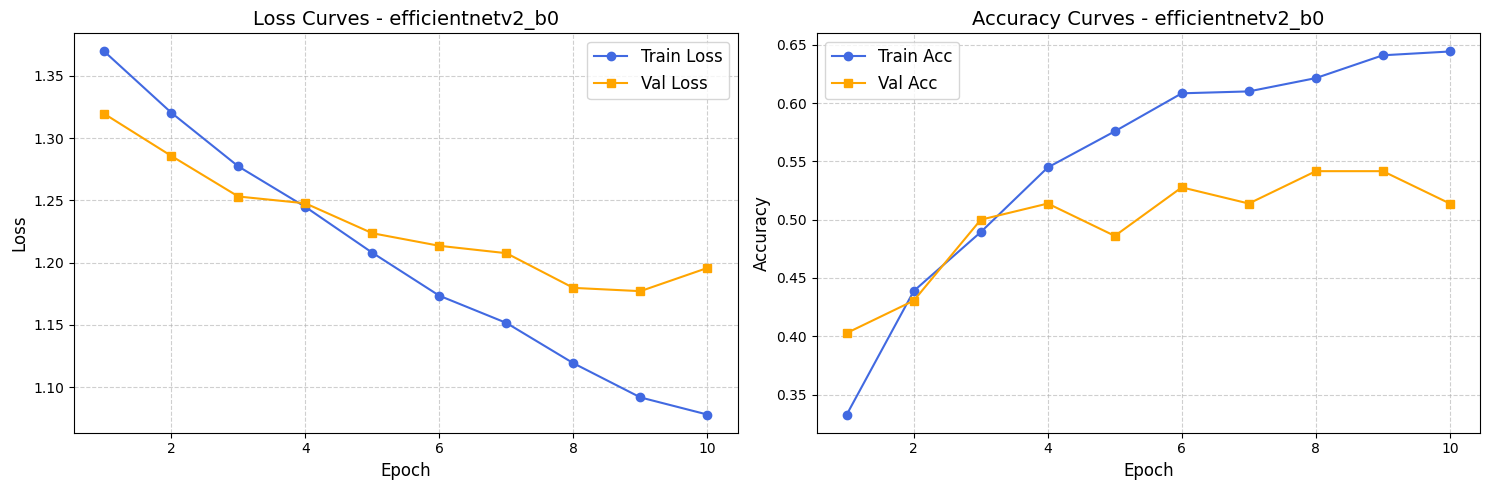

Test Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]


TEST DATASET EVALUATION: EFFICIENTNETV2_B0
Accuracy  : 0.5841
Precision : 0.6116
Recall    : 0.5466
Macro F1  : 0.5156

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.52      0.80      0.63       120
   large.cell.carcinoma       0.50      0.02      0.04        51
                 normal       0.98      1.00      0.99        54
squamous.cell.carcinoma       0.44      0.37      0.40        90

               accuracy                           0.58       315
              macro avg       0.61      0.55      0.52       315
           weighted avg       0.57      0.58      0.53       315



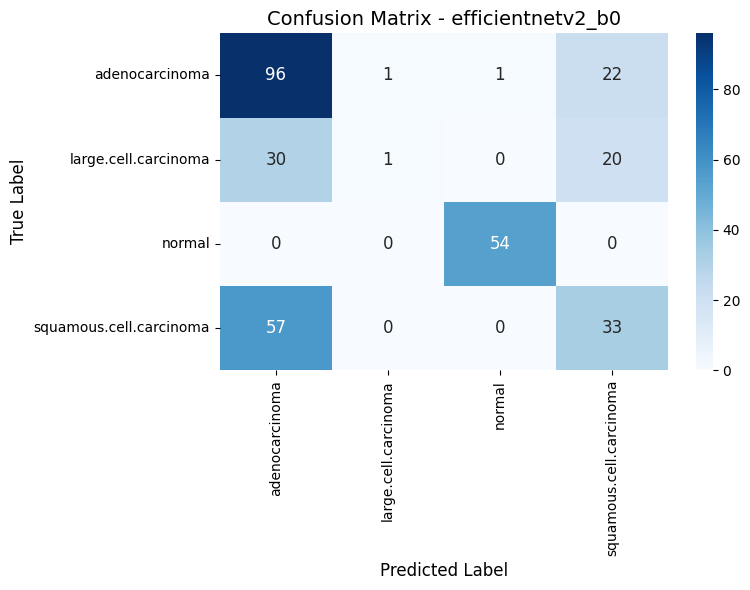

In [12]:
# ============================================================
# Evaluation on Test Dataset & Learning Curves Plotting
# ============================================================

# 1. Plot Loss & Accuracy Curves for the best overall model
best_history = all_model_histories[best_overall_model_name]
epochs = [h["epoch"] for h in best_history]
train_losses = [h["train_loss"] for h in best_history]
val_losses = [h["val_loss"] for h in best_history]
train_accs = [h["train_acc"] for h in best_history]
val_accs = [h["val_acc"] for h in best_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Plot
ax1.plot(epochs, train_losses, label="Train Loss", marker='o', color='royalblue')
ax1.plot(epochs, val_losses, label="Val Loss", marker='s', color='orange')
ax1.set_title(f"Loss Curves - {best_overall_model_name}", fontsize=14)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# Accuracy Plot
ax2.plot(epochs, train_accs, label="Train Acc", marker='o', color='royalblue')
ax2.plot(epochs, val_accs, label="Val Acc", marker='s', color='orange')
ax2.set_title(f"Accuracy Curves - {best_overall_model_name}", fontsize=14)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

# 2. Evaluate Best Model on the Test Dataset
best_overall_model.eval()
test_predictions = []
test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test Evaluation"):
        images = images.to(DEVICE)
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            outputs = best_overall_model(images)
        preds = torch.argmax(outputs, dim=1)
        test_predictions.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

test_metrics = calculate_metrics(test_labels, test_predictions)
print("\n" + "="*80)
print(f"TEST DATASET EVALUATION: {best_overall_model_name.upper()}")
print("="*80)
print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"Macro F1  : {test_metrics['f1']:.4f}")

# 3. Print Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=CLASS_NAMES, zero_division=0))

# 4. Generate & Plot Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=CLASS_NAMES, 
    yticklabels=CLASS_NAMES,
    cbar=True,
    annot_kws={"size": 12}
)
plt.title(f"Confusion Matrix - {best_overall_model_name}", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()
